<a href="https://colab.research.google.com/github/sans-mishra/Explainable_AI_Object-Detection/blob/master/YOLOv8_ObjectDetection_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Install Libraries and Frameworks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics --quiet
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
from IPython.display import display, Image as IPImage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultraly

# 2. Download and Extract VOC Dataset

In [ ]:
# Download VOC 2012 dataset
!wget -O VOCtrainval_11-May-2012.tar http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

# Extract to root
!tar -xf VOCtrainval_11-May-2012.tar

# Verify contents
!ls VOCdevkit/VOC2012


--2025-06-11 09:15:33--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.152
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1999639040 (1.9G) [application/x-tar]
Saving to: ‘VOCtrainval_11-May-2012.tar’

VOCtrainval_11-May- 100%[===================>]   1.86G  18.1MB/s    in 1m 49s  

2025-06-11 09:17:23 (17.5 MB/s) - ‘VOCtrainval_11-May-2012.tar’ saved [1999639040/1999639040]

Annotations  ImageSets	JPEGImages  SegmentationClass  SegmentationObject


# 3. Define Paths and Target Classes

In [ ]:
# Root path
voc_root = "/content/VOCdevkit/VOC2012"

# Annotations & Images
ann_dir = os.path.join(voc_root, "Annotations")
img_dir = os.path.join(voc_root, "JPEGImages")

# YOLO output folder
yolo_root = "/content/yolo_dataset"
os.makedirs(f"{yolo_root}/images/train", exist_ok=True)
os.makedirs(f"{yolo_root}/labels/train", exist_ok=True)

# Target classes
target_classes = ['dog', 'person', 'car']
class_map = {cls: idx for idx, cls in enumerate(target_classes)}

# 4. Convert VOC XMLs to YOLO Format

In [ ]:
def convert(size, box):
    dw, dh = 1. / size[0], 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return x * dw, y * dh, w * dw, h * dh

# Scan all XMLs
from pathlib import Path
xml_files = list(Path(ann_dir).glob("*.xml"))

converted = 0
skipped = 0

print("Target Classes:", target_classes)

for file in tqdm(os.listdir(ann_dir)):
    if not file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(ann_dir, file))
    root = tree.getroot()
    img_name = root.find("filename").text
    img_path = os.path.join(img_dir, img_name)

    if not os.path.exists(img_path):
        skipped += 1
        continue

    img = Image.open(img_path)
    w, h = img.size
    labels = []

    for obj in root.findall("object"):
        cls = obj.find("name").text
        if cls not in target_classes:
            continue
        xml_box = obj.find("bndbox")
        box = (
            float(xml_box.find("xmin").text),
            float(xml_box.find("xmax").text),
            float(xml_box.find("ymin").text),
            float(xml_box.find("ymax").text),
        )
        yolo_box = convert((w, h), box)
        labels.append(f"{class_map[cls]} {' '.join(map(str, yolo_box))}")

    if labels:
        shutil.copy(img_path, f"{yolo_root}/images/train/{img_name}")
        with open(f"{yolo_root}/labels/train/{file.replace('.xml', '.txt')}", 'w') as f:
            f.write('\n'.join(labels))
        converted += 1
    else:
        skipped += 1

print("\n Data Prep Summary:")
print(f" Total XMLs scanned: {len(xml_files)}")
print(f" Converted: {converted}")
print(f" Skipped (no relevant classes): {skipped}")

Target Classes: ['dog', 'person', 'car']


100%|██████████| 17125/17125 [00:14<00:00, 1202.59it/s]


 Data Prep Summary:
 Total XMLs scanned: 17125
 Converted: 11291
 Skipped (no relevant classes): 5834


#5. Create YOLOv8 data.yaml

In [ ]:
yaml_path = "/content/yolo_voc.yaml"
with open(yaml_path, 'w') as f:
    f.write(f"""
path: {yolo_root}
train: images/train
val: images/train

names:
  0: dog
  1: person
  2: car
""")

print("YAML created at:", yaml_path)

YAML created at: /content/yolo_voc.yaml


# 6. Train YOLOv8 on Custom VOC Data

In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=16,
    name="yolo-voc3class"
)

Ultralytics 8.3.153 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_voc.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo-voc3class3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

train: Scanning /content/yolo_dataset/labels/train.cache... 11291 images, 0 backgrounds, 0 corrupt: 100%|██████████| 11291/11291 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 703.1±336.8 MB/s, size: 130.0 KB)


val: Scanning /content/yolo_dataset/labels/train.cache... 11291 images, 0 backgrounds, 0 corrupt: 100%|██████████| 11291/11291 [00:00<?, ?it/s]


Plotting labels to runs/detect/yolo-voc3class3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/yolo-voc3class3
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      20/20      3.78G      0.812     0.7717      1.138         12        640: 100%|██████████| 706/706 [03:21<00:00,  3.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 353/353 [01:29<00:00,  3.93it/s]


                   all      11291      21491      0.821      0.762      0.841      0.663

20 epochs completed in 1.674 hours.
Optimizer stripped from runs/detect/yolo-voc3class3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolo-voc3class3/weights/best.pt, 6.2MB

Validating runs/detect/yolo-voc3class3/weights/best.pt...
Ultralytics 8.3.153 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 353/353 [01:32<00:00,  3.80it/s]


                   all      11291      21491       0.82      0.762      0.841      0.663
                   dog       1341       1598      0.843      0.859      0.903      0.741
                person       9583      17401      0.808      0.796       0.86      0.676
                   car       1284       2492       0.81      0.631      0.761      0.572
Speed: 0.2ms preprocess, 1.8ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/yolo-voc3class3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791559d29110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
# Save best.pt
source_path = "runs/detect/yolo-voc3class3/weights/best.pt"
destination_path = "/content/drive/MyDrive/YOLO_Models/best_voc3class.pt"

# Create directory if it doesn't exist
!mkdir -p /content/drive/MyDrive/YOLO_Models

# Copy the model
!cp {source_path} {destination_path}

In [ ]:
# Paths
source_path = "runs/detect/yolo-voc3class3/results.png"
destination_path = "/content/drive/MyDrive/YOLO_Results/results_voc3class.png"

# Create the destination folder if it doesn't exist
!mkdir -p /content/drive/MyDrive/YOLO_Results

# Copy the file
!cp {source_path} {destination_path}

# Save more training visualizations
additional_files = [
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in additional_files:
    !cp runs/detect/yolo-voc3class3/{file} /content/drive/MyDrive/YOLO_Results/

In [ ]:
import os

# ✅ Create all necessary directories in Drive
os.system("mkdir -p /content/drive/MyDrive/YOLO_Backup/YOLO_Models")
os.system("mkdir -p /content/drive/MyDrive/YOLO_Backup/YOLO_Results/full_run")
os.system("mkdir -p /content/drive/MyDrive/YOLO_Backup/YOLO_Dataset")

# ✅ Save trained model
os.system("cp runs/detect/yolo-voc3class3/weights/best.pt /content/drive/MyDrive/YOLO_Backup/YOLO_Models/best_voc3class.pt")

# ✅ Save training plots
plots = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "labels.jpg",
    "labels_correlogram.jpg"
]

for plot in plots:
    os.system(f"cp runs/detect/yolo-voc3class3/{plot} /content/drive/MyDrive/YOLO_Backup/YOLO_Results/")

# Save entire run folder (includes prediction images, metrics, etc.)
os.system("cp -r runs/detect/yolo-voc3class3/* /content/drive/MyDrive/YOLO_Backup/YOLO_Results/full_run/")

# Save data.yaml (class mappings file)
os.system("cp data.yaml /content/drive/MyDrive/YOLO_Backup/YOLO_Results/data.yaml")

# Save dataset (VOC format)
os.system("cp -r VOCdevkit /content/drive/MyDrive/YOLO_Backup/YOLO_Dataset/")


0

# 7. Run Inference on Sample Images

📦 Predictions:

image 1/1 /content/yolo_dataset/images/train/2011_005724.jpg: 480x640 5 persons, 11.1ms
Speed: 2.9ms preprocess, 11.1ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict2


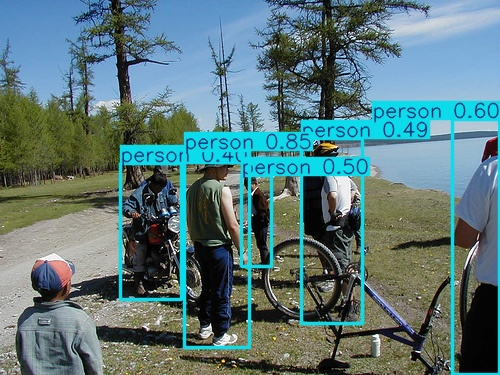


image 1/1 /content/yolo_dataset/images/train/2009_004630.jpg: 480x640 9 cars, 11.9ms
Speed: 2.9ms preprocess, 11.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict2


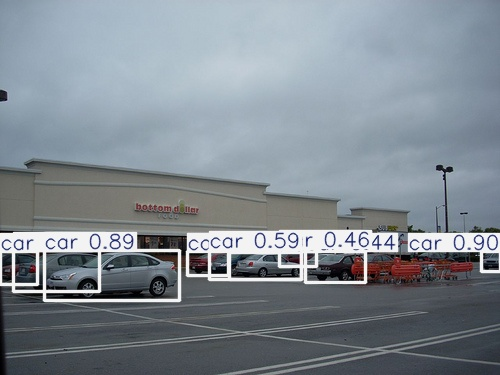


image 1/1 /content/yolo_dataset/images/train/2011_003642.jpg: 480x640 2 persons, 11.3ms
Speed: 3.9ms preprocess, 11.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict2


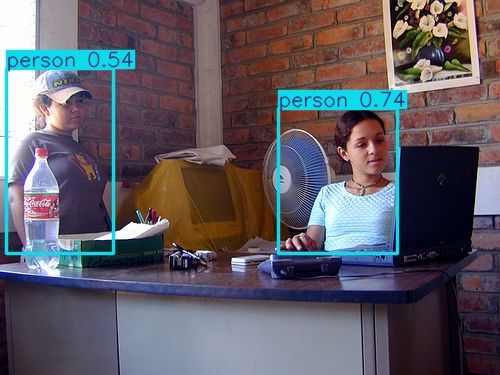

In [ ]:
# Load trained YOLO model
model = YOLO("/content/drive/MyDrive/YOLO_Models/best_voc3class.pt")

# Choose a few images for prediction
sample_imgs = os.listdir(f"{yolo_root}/images/train")[20:23]

print("📦 Predictions:")
for img_name in sample_imgs:
    img_path = os.path.join(yolo_root, "images/train", img_name)

    # Run inference and save the result
    results = model.predict(source=img_path, conf=0.3, save=True)

    # Safely construct the path to the saved result
    saved_img_path = os.path.join(results[0].save_dir, img_name)
    display(IPImage(filename=saved_img_path))


# 8. Evaluate Model

In [ ]:
metrics = model.val()
print("Metrics:", metrics)

Ultralytics 8.3.153 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1765.1±658.2 MB/s, size: 88.9 KB)


val: Scanning /content/yolo_dataset/labels/train.cache... 11291 images, 0 backgrounds, 0 corrupt: 100%|██████████| 11291/11291 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 706/706 [01:42<00:00,  6.91it/s]


                   all      11291      21491      0.821      0.763      0.841      0.663
                   dog       1341       1598      0.844       0.86      0.902      0.741
                person       9583      17401      0.807      0.796       0.86      0.676
                   car       1284       2492      0.811      0.632      0.762      0.572
Speed: 0.3ms preprocess, 2.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val
Metrics: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7914b2f5a450>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.0120

# 9. Training Metrics Plot

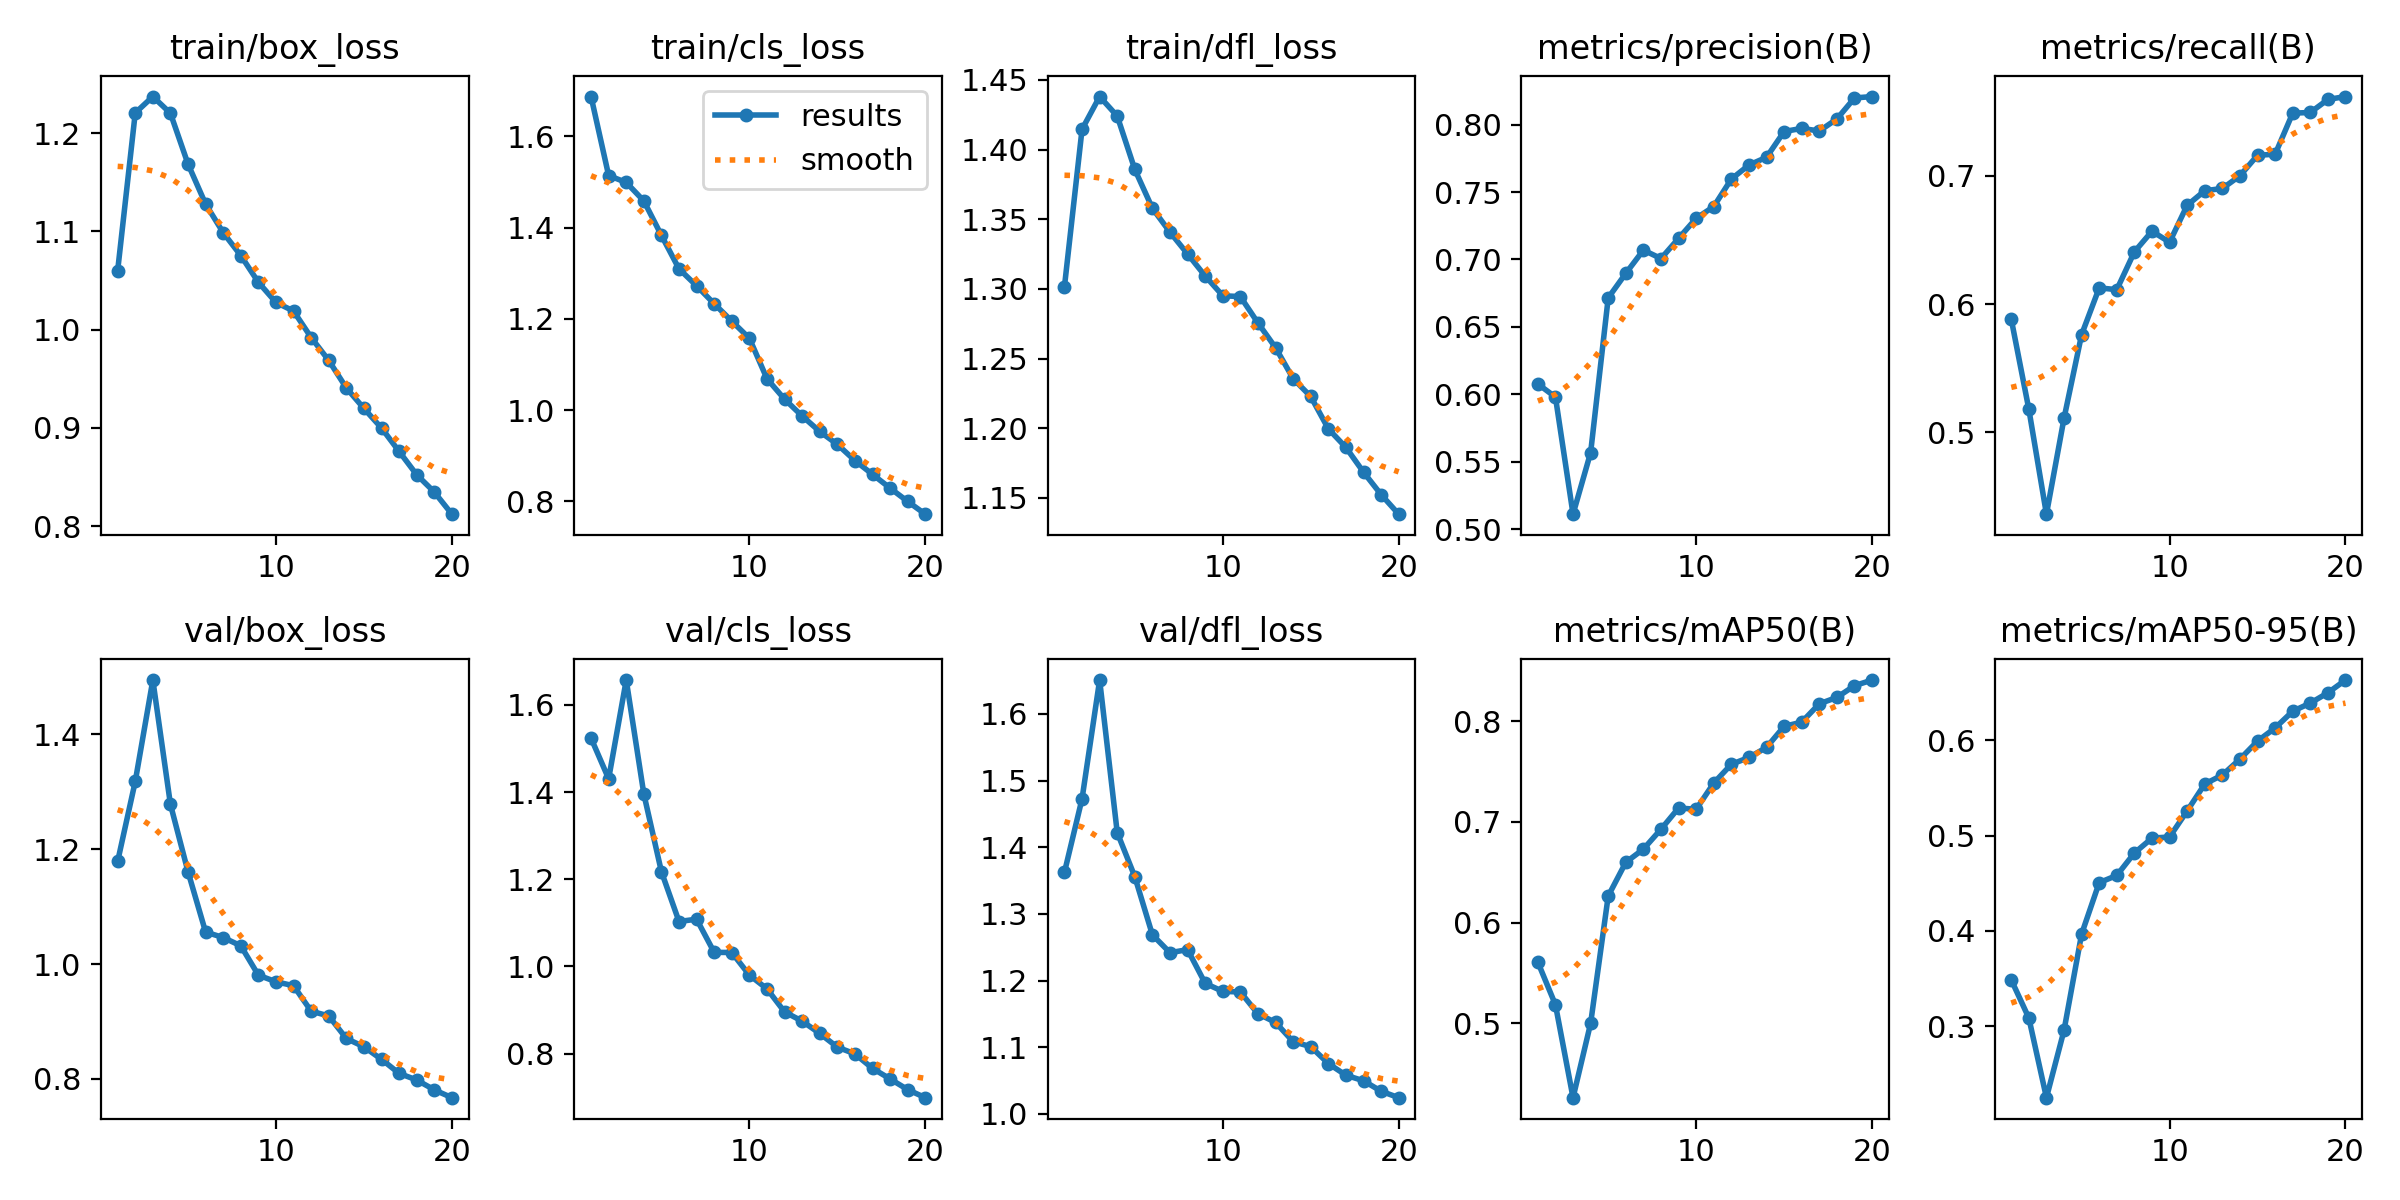

In [ ]:
from IPython.display import Image, display

# Training results plot
display(Image(filename='/content/drive/MyDrive/YOLO_Results/results_voc3class.png'))

Running inference on test images

image 1/1 /content/VOCdevkit/VOC2012/JPEGImages/2011_000007.jpg: 640x480 1 person, 10.3ms
Speed: 2.9ms preprocess, 10.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs/detect/predict7


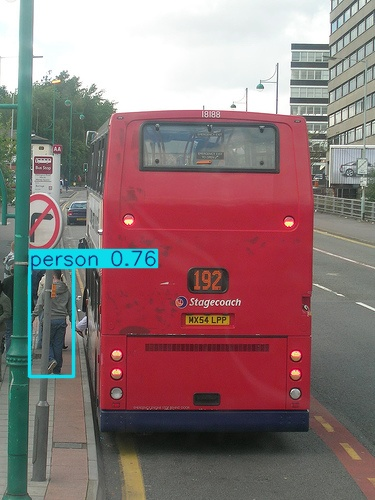

Predictions for: 2011_000007.jpg
 → Class: person, Confidence: 0.76, Box: [29.36446762084961, 267.22412109375, 73.41661071777344, 376.5289306640625]
------------------------------------------------------------

image 1/1 /content/VOCdevkit/VOC2012/JPEGImages/2008_002032.jpg: 480x640 6 persons, 9.8ms
Speed: 2.7ms preprocess, 9.8ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict7


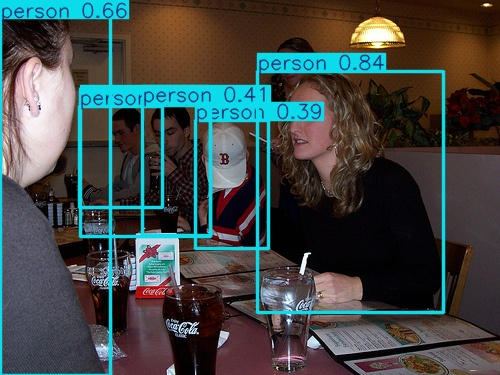

Predictions for: 2008_002032.jpg
 → Class: person, Confidence: 0.84, Box: [257.9851989746094, 71.17314147949219, 443.176513671875, 312.6431579589844]
 → Class: person, Confidence: 0.66, Box: [0.06079673767089844, 0.0, 110.47486877441406, 375.0]
 → Class: person, Confidence: 0.41, Box: [142.72193908691406, 103.12626647949219, 210.25437927246094, 235.37869262695312]
 → Class: person, Confidence: 0.39, Box: [195.1767578125, 120.60017395019531, 268.7096252441406, 248.88287353515625]
 → Class: person, Confidence: 0.38, Box: [79.82368469238281, 106.57698822021484, 162.62417602539062, 207.5777587890625]
 → Class: person, Confidence: 0.30, Box: [80.12255096435547, 103.23648071289062, 210.11474609375, 236.92428588867188]
------------------------------------------------------------

image 1/1 /content/VOCdevkit/VOC2012/JPEGImages/2011_000090.jpg: 480x640 1 person, 11.1ms
Speed: 5.6ms preprocess, 11.1ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/

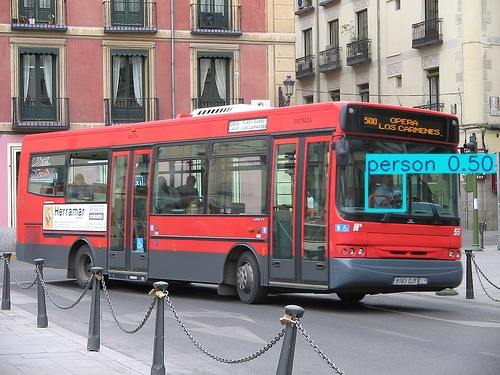

Predictions for: 2011_000090.jpg
 → Class: person, Confidence: 0.50, Box: [366.285888671875, 172.60177612304688, 404.9014892578125, 210.78553771972656]
------------------------------------------------------------


In [ ]:
from ultralytics import YOLO
from IPython.display import Image as IPImage, display
import os
import random

# Load trained model from Google Drive
model = YOLO('/content/drive/MyDrive/YOLO_Models/best_voc3class.pt')

# Directory containing test images
test_dir = "VOCdevkit/VOC2012/JPEGImages"
test_images = os.listdir(test_dir)

# Select a few random test images
sample_imgs = random.sample(test_images, 3)

# Run inference and display results
print("Running inference on test images")
for img_name in sample_imgs:
    img_path = os.path.join(test_dir, img_name)
    results = model.predict(source=img_path, save=True, conf=0.25)

    # Display image with bounding boxes
    display(IPImage(filename=os.path.join(str(results[0].save_dir), img_name)))

    # Print bounding box details
    print(f"Predictions for: {img_name}")
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
        print(f" → Class: {cls_name}, Confidence: {conf:.2f}, Box: {xyxy}")
    print("-" * 60)